# Employee Attrition Prediction — EDA & Model Training
### Phase 4 (EDA) + Phase 5 (Machine Learning Development)

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle) — 1,470 employees, 35 columns.

**Goals of this notebook**
1. Explore the dataset and understand attrition patterns (EDA)
2. Clean and prepare the data for modeling
3. Handle class imbalance properly (SMOTE + class weighting)
4. Train and compare multiple classifiers using stratified cross-validation
5. Evaluate using Precision / Recall / F1 / ROC-AUC (not accuracy alone)
6. Select and save the best model with `joblib`, tagged with a version identifier

> Class imbalance note: only ~16% of employees in this dataset actually leave. A model that
> just predicts "Stay" for everyone would score ~84% accuracy while being useless. Every step
> below is written to guard against that failure mode specifically.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42


## 2. Load Dataset

In [2]:
df = pd.read_csv("data/employee_attrition.csv")
print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### 2.1 Missing values and duplicates check

In [4]:
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate EmployeeNumber:", df['EmployeeNumber'].duplicated().sum())


Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0
Duplicate EmployeeNumber: 0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target distribution (the class imbalance we need to handle)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


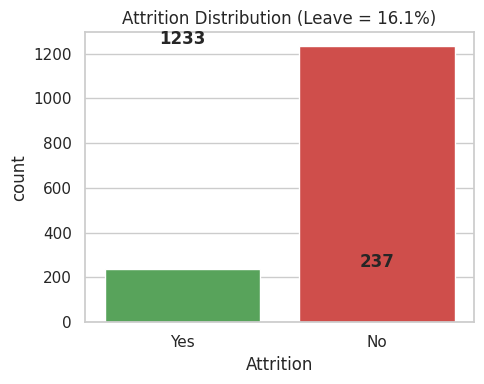

In [5]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_counts)
print(attrition_pct.round(1))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=['#4CAF50', '#E53935'], legend=False, ax=ax)
ax.set_title(f"Attrition Distribution (Leave = {attrition_pct['Yes']:.1f}%)")
for i, v in enumerate(attrition_counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Attrition by key categorical drivers

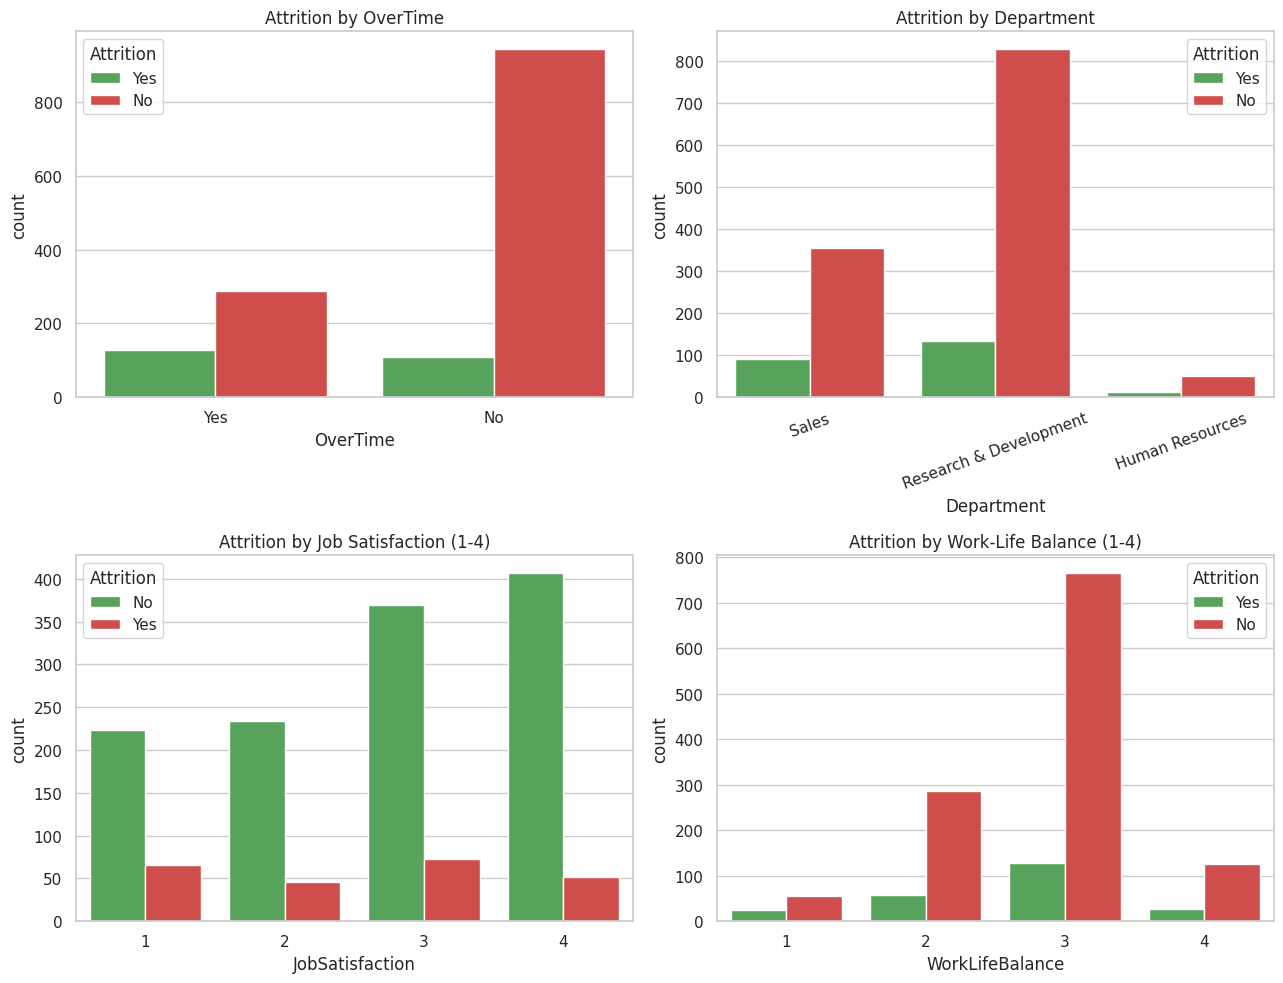

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0,0], palette=['#4CAF50', '#E53935'])
axes[0,0].set_title('Attrition by OverTime')

sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[0,1], palette=['#4CAF50', '#E53935'])
axes[0,1].set_title('Attrition by Department')
axes[0,1].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1,0], palette=['#4CAF50', '#E53935'])
axes[1,0].set_title('Attrition by Job Satisfaction (1-4)')

sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition', ax=axes[1,1], palette=['#4CAF50', '#E53935'])
axes[1,1].set_title('Attrition by Work-Life Balance (1-4)')

plt.tight_layout()
plt.show()


### 3.3 Attrition by numeric drivers (age, income, years at company)

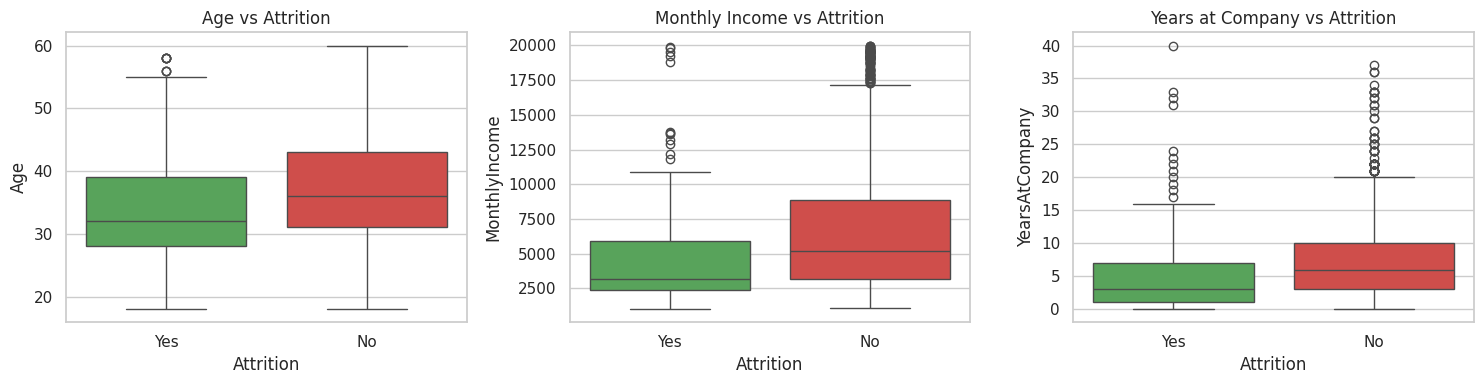

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='Attrition', y='Age', hue='Attrition', palette=['#4CAF50', '#E53935'], legend=False, ax=axes[0])
axes[0].set_title('Age vs Attrition')

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette=['#4CAF50', '#E53935'], legend=False, ax=axes[1])
axes[1].set_title('Monthly Income vs Attrition')

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', hue='Attrition', palette=['#4CAF50', '#E53935'], legend=False, ax=axes[2])
axes[2].set_title('Years at Company vs Attrition')

plt.tight_layout()
plt.show()


**Typical patterns to expect in this dataset** (validate against your own output above):
- Employees who work overtime leave at a noticeably higher rate
- Lower job satisfaction and poor work-life balance correlate with higher attrition
- Younger employees and those with fewer years at the company tend to leave more
- Lower monthly income correlates with higher attrition

### 3.4 Correlation heatmap (numeric features only)

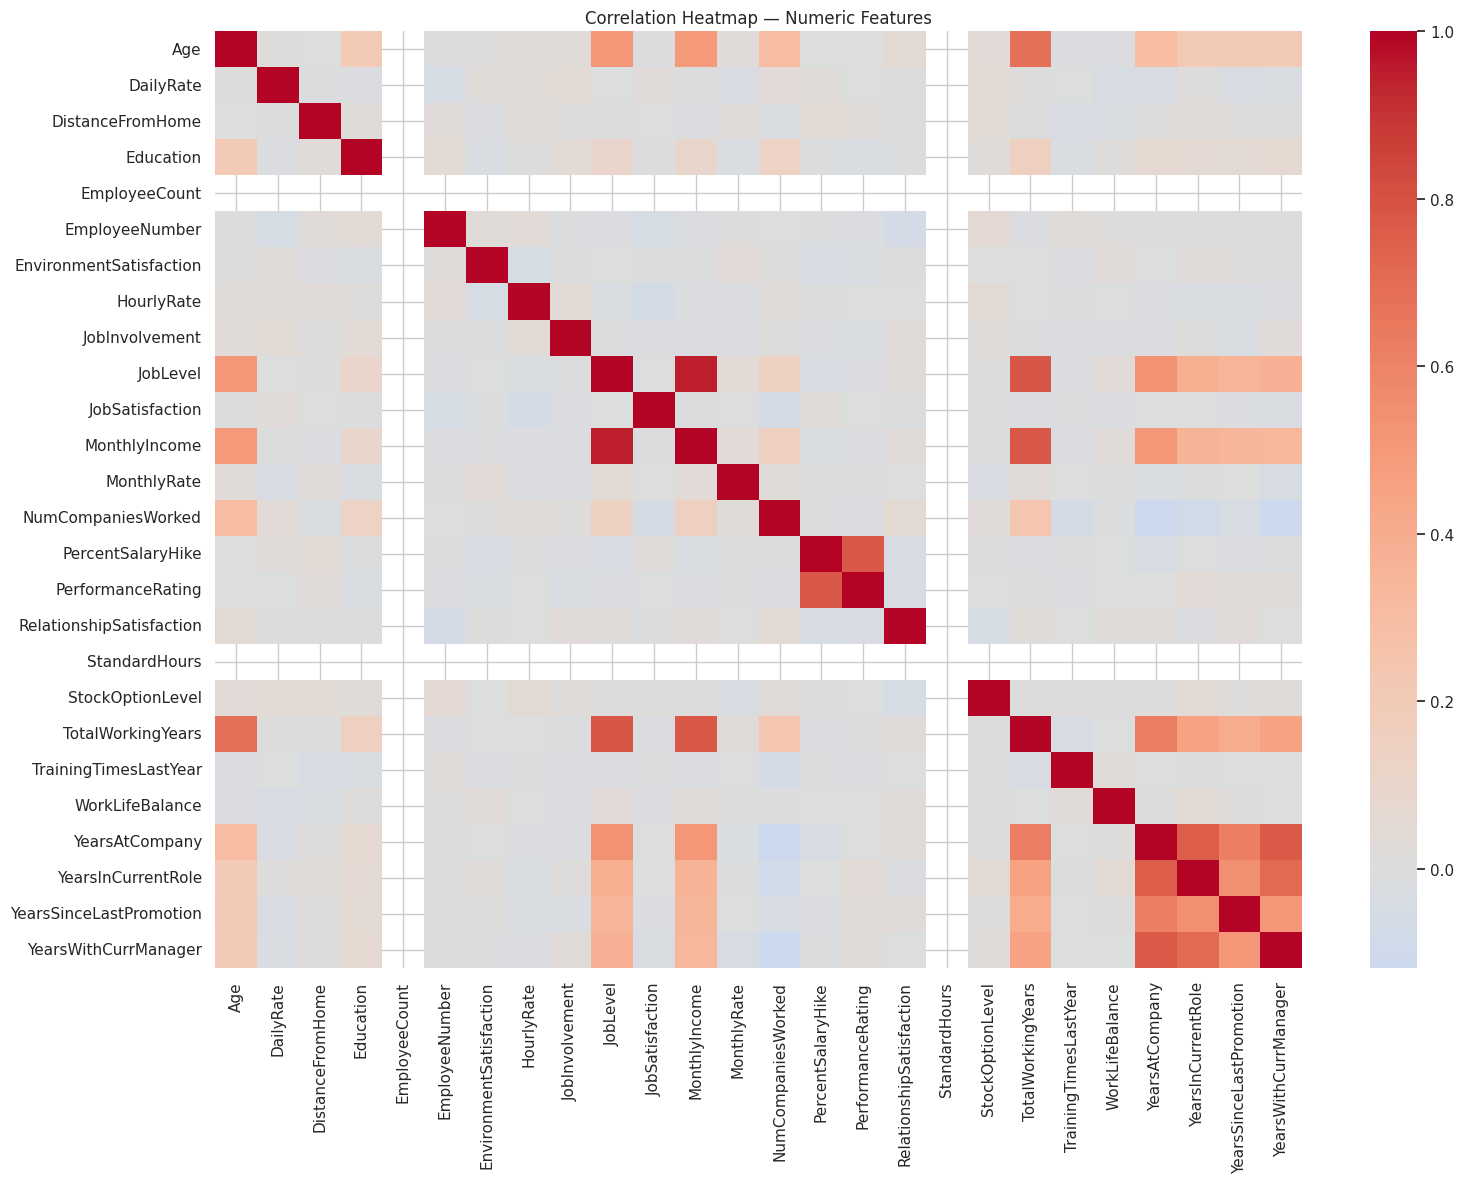

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()


## 4. Data Cleaning & Feature Preparation

Drop columns that carry no predictive value:
- `EmployeeCount`, `StandardHours`, `Over18` — constant across all rows
- `EmployeeNumber` — identifier, not a feature


In [9]:
constant_cols = [c for c in ['EmployeeCount', 'StandardHours', 'Over18'] if df[c].nunique() == 1]
print("Confirmed constant columns:", constant_cols)

drop_cols = constant_cols + ['EmployeeNumber']
data = df.drop(columns=drop_cols)
print("Remaining shape:", data.shape)


Confirmed constant columns: ['EmployeeCount', 'StandardHours', 'Over18']
Remaining shape: (1470, 31)


### 4.1 Encode target and categorical features

In [10]:
target_col = 'Attrition'
data[target_col] = data[target_col].map({'Yes': 1, 'No': 0})

categorical_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-hot encode categoricals (keeps this readable/model-agnostic;
# avoids implying false ordinal relationships between categories)
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", data_encoded.shape)


Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


/tmp/ipykernel_568/4153596478.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include='object').columns.tolist()


## 5. Train / Test Split (Stratified)

`stratify=y` ensures both the train and test sets preserve the same ~16% attrition rate —
without this, a random split could easily leave the test set with too few "Leave" examples
to evaluate reliably.

In [11]:
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Attrition rate:", y_train.mean().round(3))
print("Test shape: ", X_test.shape, " Attrition rate:", y_test.mean().round(3))


Train shape: (1176, 44)  Attrition rate: 0.162
Test shape:  (294, 44)  Attrition rate: 0.16


### 5.1 Scale numeric features (helps Logistic Regression converge properly)

In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 6. Handle Class Imbalance with SMOTE

**Critical:** SMOTE is fit only on the training set. The test set must stay untouched and
reflect the real-world ~16% attrition rate, or evaluation metrics become misleading.

In [13]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE: ", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}


## 7. Model Training & Comparison

Three candidate models, each evaluated two ways:
1. **5-fold stratified cross-validation on the SMOTE-balanced training data** — gives a stable
   estimate of generalization performance rather than relying on one lucky/unlucky split.
2. **Held-out test set** (real-world imbalance, untouched by SMOTE) — the number that actually
   matters, since it reflects how the model performs in production.

Logistic Regression and Random Forest use `class_weight='balanced'` as an additional safeguard
on top of SMOTE. XGBoost uses `scale_pos_weight` for the same reason.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['f1', 'precision', 'recall', 'roc_auc']

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_sm, y_train_sm, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in scoring}
    print(f"{name}: " + ", ".join(f"{m}={v:.3f}" for m, v in cv_results[name].items()))

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df


Logistic Regression: f1=0.799, precision=0.787, recall=0.813, roc_auc=0.887


Random Forest: f1=0.930, precision=0.963, recall=0.900, roc_auc=0.980


XGBoost: f1=0.914, precision=0.897, recall=0.932, roc_auc=0.974


,f1,precision,recall,roc_auc
Logistic Regression,0.799405,0.786619,0.813393,0.887172
Random Forest,0.929790,0.962891,0.899595,0.979517
XGBoost,0.914122,0.897460,0.932046,0.973598


### 7.1 Fit each model on the full SMOTE-balanced training set, evaluate on the real (untouched) test set

In [15]:
test_results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

test_results_df = pd.DataFrame(test_results).T.round(3)
print(test_results_df)


                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.776      0.373   0.596  0.459    0.785
Random Forest           0.847      0.536   0.319  0.400    0.809
XGBoost                 0.820      0.435   0.426  0.430    0.766


**Why look at more than accuracy:** a model that predicts "Stay" for every employee would
still score ~84% accuracy on this test set while having 0% recall on the "Leave" class — i.e. it
would never catch a single at-risk employee. **Recall and F1 on the minority class are what
actually matter for this system's purpose.**

### 7.2 Confusion matrices for all three models

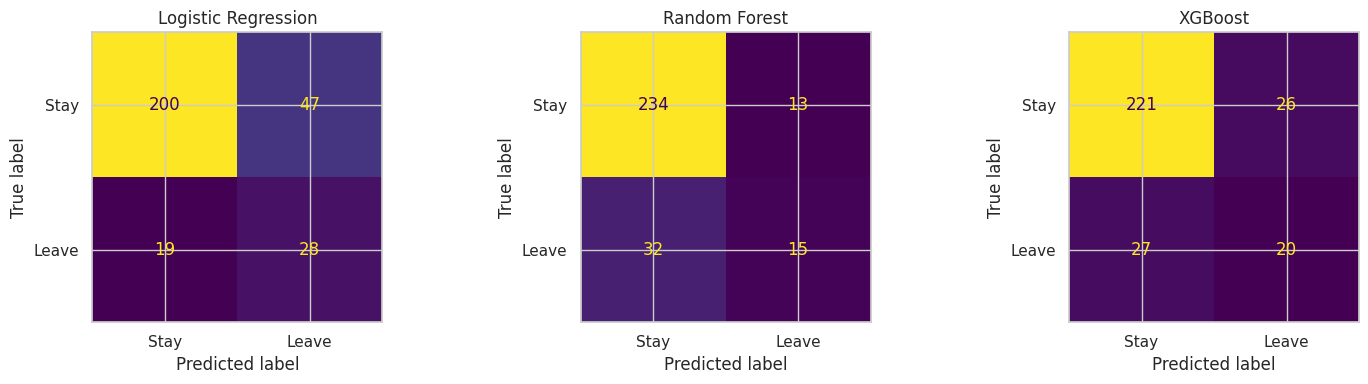

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Leave']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### 7.3 ROC curves

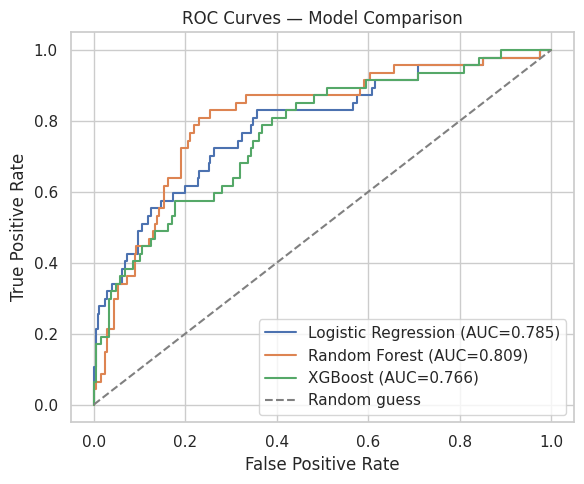

In [17]:
plt.figure(figsize=(6, 5))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Select Best Model

Selection is based primarily on **F1-score and ROC-AUC on the untouched test set** — not
accuracy — since correctly identifying likely leavers (recall) matters as much as not
over-flagging stayers (precision) for this system's purpose.

In [18]:
best_model_name = test_results_df['f1'].idxmax()
best_model = fitted_models[best_model_name]

print("Selected model:", best_model_name)
print(test_results_df.loc[best_model_name])
print("\nFull classification report:\n")
print(classification_report(y_test, best_model.predict(X_test_scaled), target_names=['Stay', 'Leave']))


Selected model: Logistic Regression
accuracy     0.776
precision    0.373
recall       0.596
f1           0.459
roc_auc      0.785
Name: Logistic Regression, dtype: float64

Full classification report:

              precision    recall  f1-score   support

        Stay       0.91      0.81      0.86       247
       Leave       0.37      0.60      0.46        47

    accuracy                           0.78       294
   macro avg       0.64      0.70      0.66       294
weighted avg       0.83      0.78      0.79       294



## 9. Save Model, Scaler, and Feature Schema

Saved together so the FastAPI service (Phase 6) can load and use them consistently:
- `model.pkl` — the trained classifier
- `scaler.pkl` — the fitted `StandardScaler` (must be applied to new input the same way)
- `feature_columns.json` — the exact column order/names after one-hot encoding, so incoming
  API requests can be encoded identically to training data
- `model_metadata.json` — version tag, training date, and test metrics, matching the
  `model_version` field already designed into the `predictions` table


In [19]:
MODEL_VERSION = f"{best_model_name.lower().replace(' ', '_')}_v1_{datetime.now().strftime('%Y-%m-%d')}"

joblib.dump(best_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

with open("models/feature_columns.json", "w") as f:
    json.dump(list(X.columns), f, indent=2)

metadata = {
    "model_version": MODEL_VERSION,
    "model_type": best_model_name,
    "trained_at_utc": datetime.utcnow().isoformat(),
    "training_rows": int(len(X_train_sm)),
    "test_rows": int(len(X_test)),
    "test_metrics": {k: round(float(v), 4) for k, v in test_results[best_model_name].items()},
}
with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model version:", MODEL_VERSION)
print(json.dumps(metadata, indent=2))


Saved model version: logistic_regression_v1_2026-08-25
{
  "model_version": "logistic_regression_v1_2026-08-25",
  "model_type": "Logistic Regression",
  "trained_at_utc": "2026-08-25T08:10:48.299586",
  "training_rows": 1972,
  "test_rows": 294,
  "test_metrics": {
    "accuracy": 0.7755,
    "precision": 0.3733,
    "recall": 0.5957,
    "f1": 0.459,
    "roc_auc": 0.7854
  }
}


/tmp/ipykernel_568/257630838.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc": datetime.utcnow().isoformat(),


## 10. Next Step — Phase 6

`models/model.pkl`, `models/scaler.pkl`, and `models/feature_columns.json` are now ready to be
loaded by the FastAPI `/predict` service. The `model_version` string saved in
`model_metadata.json` should be stored with every prediction row in the `predictions` table,
exactly as designed in the finalized project document.
